# Social Network Ads Classification using K-Nearest Neighbors (K-NN)

**Repositori**: Machine Learning  
**Topik**: Implementasi K-Nearest Neighbors pada Klasifikasi Social Network Ads  
**Dataset**: `Social_Network_Ads.csv`  

---

## Pendahuluan
Proyek ini menggunakan **K-Nearest Neighbors** untuk memprediksi apakah pengguna akan membeli produk berdasarkan **Age** dan **EstimatedSalary**. K-NN mengklasifikasikan data baru berdasarkan kemiripan dengan tetangga terdekatnya menggunakan jarak Manhattan.

### Pipeline:
1. **Data Acquisition** — Muat CSV
2. **EDA** — Analisis distribusi data
3. **Data Preparation** — Split train/test
4. **Feature Scaling** — StandardScaler
5. **Modeling** — K-NN (k=3, Manhattan distance)
6. **Evaluation** — Confusion Matrix + Classification Report
7. **Visualization** — Decision Boundary

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report

sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

## 1. Data Acquisition
Memuat dataset dan melihat struktur data.

In [2]:
df = pd.read_csv('../../data/Social_Network_Ads.csv')
print("Shape:", df.shape)
df.head()

Shape: (400, 5)


,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


## 2. Exploratory Data Analysis

In [3]:
print("Informasi Dataset:")
df.info()

print("\nStatistik Deskriptif:")
print(df[['Age', 'EstimatedSalary', 'Purchased']].describe())

print("\nDistribusi Target:")
print(df['Purchased'].value_counts())
print(df['Purchased'].value_counts(normalize=True).mul(100).round(2).apply(lambda x: f"{x}%"))

Informasi Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   User ID          400 non-null    int64 
 1   Gender           400 non-null    object
 2   Age              400 non-null    int64 
 3   EstimatedSalary  400 non-null    int64 
 4   Purchased        400 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 15.8+ KB

Statistik Deskriptif:
              Age  EstimatedSalary   Purchased
count  400.000000       400.000000  400.000000
mean    37.655000     69742.500000    0.357500
std     10.482877     34096.960282    0.479864
min     18.000000     15000.000000    0.000000
25%     29.750000     43000.000000    0.000000
50%     37.000000     70000.000000    0.000000
75%     46.000000     88000.000000    1.000000
max     60.000000    150000.000000    1.000000

Distribusi Target:
Purchased
0    257
1    143
Name: count, dtyp

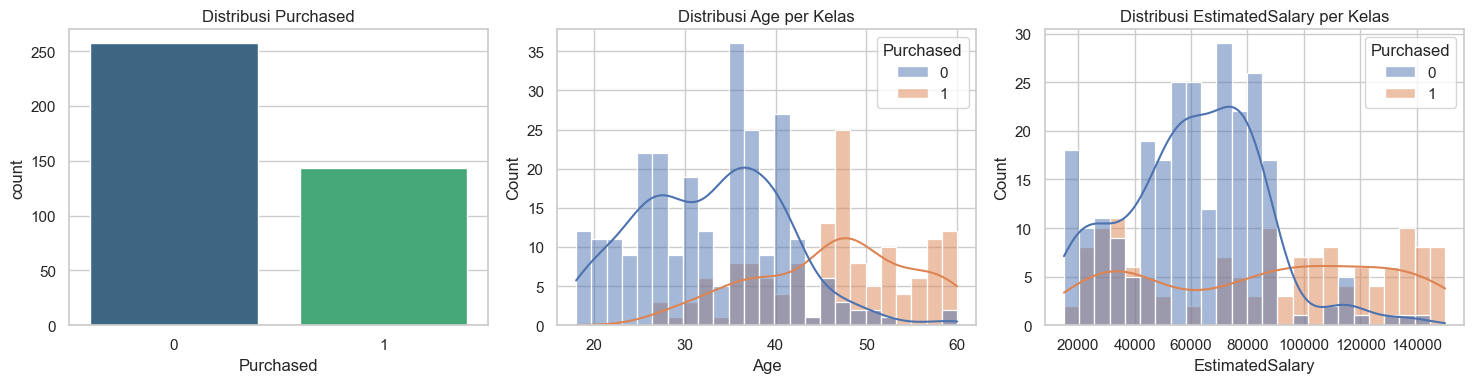

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.countplot(x='Purchased', data=df, hue='Purchased', palette='viridis', legend=False, ax=axes[0])
axes[0].set_title('Distribusi Purchased')

sns.histplot(data=df, x='Age', hue='Purchased', bins=25, kde=True, ax=axes[1])
axes[1].set_title('Distribusi Age per Kelas')

sns.histplot(data=df, x='EstimatedSalary', hue='Purchased', bins=25, kde=True, ax=axes[2])
axes[2].set_title('Distribusi EstimatedSalary per Kelas')

plt.tight_layout()
plt.show()

## 3. Data Preparation
Memisahkan fitur dan target, lalu split ke Training dan Test set.

In [5]:
X = df[['Age', 'EstimatedSalary']].values
y = df['Purchased'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=0
)

print(f"Train size: {X_train.shape[0]} samples")
print(f"Test size:  {X_test.shape[0]} samples")

Train size: 300 samples
Test size:  100 samples


## 4. Feature Scaling
Standardisasi fitur agar perhitungan jarak Euclidean/Manhattan tidak didominasi oleh fitur dengan skala besar.

In [6]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## 5. Model Training (K-Nearest Neighbors)
Menggunakan `k=3` dengan **Manhattan distance** (`p=1`).

In [7]:
model = KNeighborsClassifier(n_neighbors=3, metric='manhattan', p=1)
model.fit(X_train, y_train)
print("Model trained:", model)

Model trained: KNeighborsClassifier(metric='manhattan', n_neighbors=3, p=1)


## 6. Prediction & Evaluation

Confusion Matrix:
[[64  4]
 [ 3 29]]


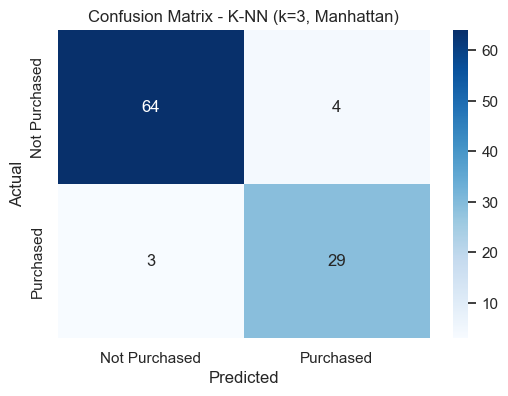


Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.94      0.95        68
           1       0.88      0.91      0.89        32

    accuracy                           0.93       100
   macro avg       0.92      0.92      0.92       100
weighted avg       0.93      0.93      0.93       100



In [8]:
y_pred = model.predict(X_test)

print("Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Purchased', 'Purchased'],
            yticklabels=['Not Purchased', 'Purchased'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - K-NN (k=3, Manhattan)')
plt.show()

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

## 7. Decision Boundary Visualization
Fungsi helper untuk plotting decision boundary.

In [9]:
def plot_decision_boundary(model, X_set, y_set, title, labels=None):
    X1, X2 = np.meshgrid(
        np.arange(X_set[:, 0].min() - 1, X_set[:, 0].max() + 1, 0.01),
        np.arange(X_set[:, 1].min() - 1, X_set[:, 1].max() + 1, 0.01),
    )
    Z = model.predict(np.c_[X1.ravel(), X2.ravel()]).reshape(X1.shape)

    plt.contourf(X1, X2, Z, alpha=0.75, cmap=ListedColormap(('red', 'green')))
    plt.xlim(X1.min(), X1.max())
    plt.ylim(X2.min(), X2.max())

    colors = ListedColormap(('red', 'green')).colors
    for i, j in enumerate(np.unique(y_set)):
        plt.scatter(
            X_set[y_set == j, 0], X_set[y_set == j, 1],
            color=colors[i], label=labels[i] if labels else j,
            edgecolor='black', s=50,
        )

    plt.title(title)
    plt.xlabel('Age (scaled)')
    plt.ylabel('Estimated Salary (scaled)')
    plt.legend()
    plt.show()

### Training Set

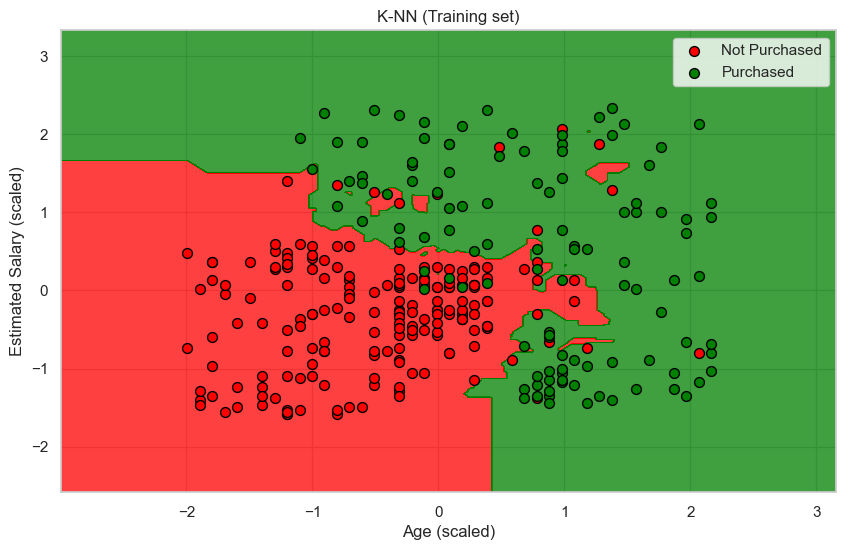

In [10]:
plot_decision_boundary(
    model, X_train, y_train,
    title='K-NN (Training set)',
    labels=['Not Purchased', 'Purchased'],
)

### Test Set

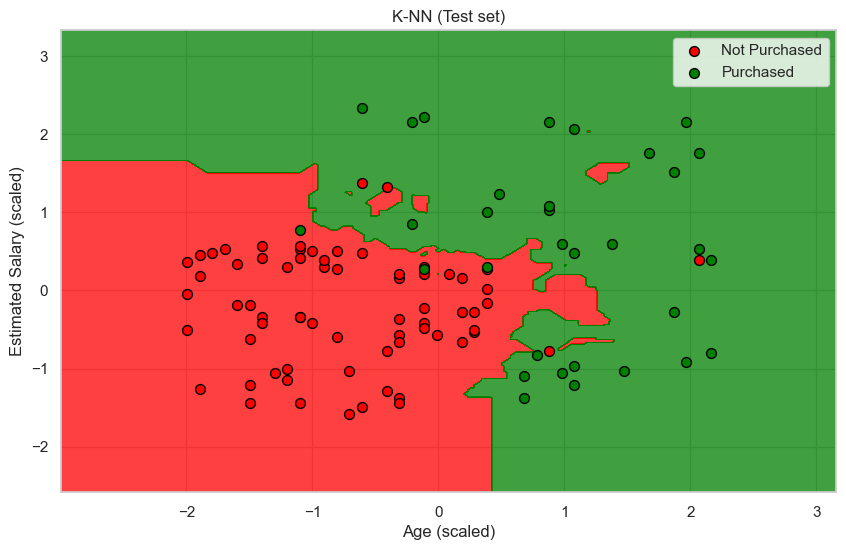

In [11]:
plot_decision_boundary(
    model, X_test, y_test,
    title='K-NN (Test set)',
    labels=['Not Purchased', 'Purchased'],
)

## Kesimpulan
Model **K-NN (k=3, Manhattan distance)** berhasil mengklasifikasikan pembeli vs bukan pembeli dengan accuracy ~93%. Decision boundary yang berkelok-kelok menunjukkan fleksibilitas K-NN dalam menangkap pola data non-linear.